In [2]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
from skimage.transform import radon, iradon
from skimage.restoration import denoise_tv_chambolle
import astra # https://astra-toolbox.com/docs/index.html
astra.test();

ASTRA Toolbox v2.4.1
Getting GPU info... GPU #0: Quadro T1000 with Max-Q Design, with 4095MB, CUDA compute capability 7.5
Testing basic CPU 2D functionality... Ok
Testing basic CUDA 2D functionality... Ok
Testing basic CUDA 3D functionality... Ok


# Load Dataset
Using XCAT dataset 'sampling_300ms_compressed.mat'.
This data originally has dimensions 400x400x50x100. I.e. 100 samples of 50 slices, each 400x400.
Opening the dataset using h5py reverses the order, so it is now 100x50x400x400.

In [3]:
file = h5py.File('data/sampling_300ms_compressed.mat', 'r');
data = file['data2'];

N = 400; # NxN images
SLICES = 50; # slices per sample
SAMPLES = 100; 

print(f"Number of samples: {len(data)}");
print(f"Number of slices: {len(data[0,:,:,:])}");
print(f"Dimensions: {len(data[0,0,:,:])}x{len(data[0,0,0,:])}");

Number of samples: 100
Number of slices: 50
Dimensions: 400x400


In [15]:
# Remember to close the file when done
file.close();

## Test Example

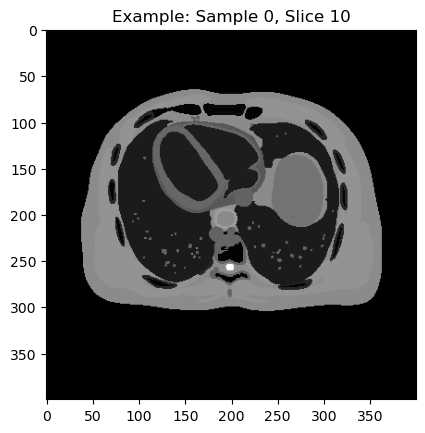

In [23]:
# Example to test loaded, extracting one slice at sample 0, slice 10
ex_image = data[14, 10, :, :];
ex_image = np.rot90(ex_image, k=-1, axes=(0,1)); # rotate 90 deg clockwise
plot = plt.figure();
plot = plt.imshow(ex_image, cmap='grey');
plt.title("Example: Sample 0, Slice 10");
plt.savefig('fig/example_slice.png');
plt.show(plot)

# Breathing Cycle Animation

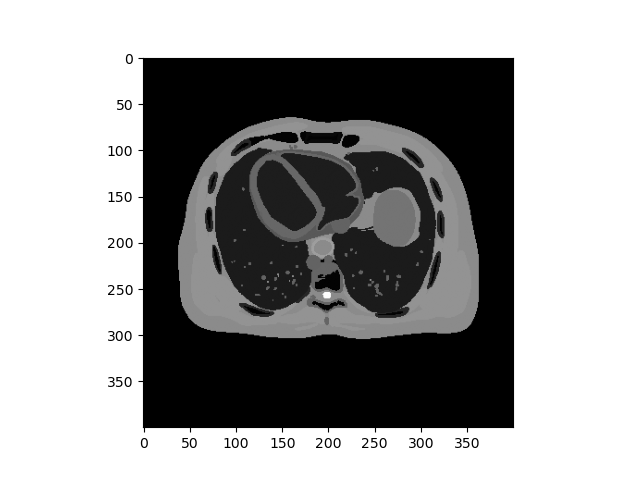

In [14]:
# Animation to demonstrate breathing cycle in XCAT
import matplotlib.animation as animation
from IPython.display import Image, display

start = 0;
end = 14 + 1;
#end = 88 + 1;

images = data[start:end-1, 10, :, :];
images = np.rot90(images, k=-1, axes=(1,2));

im = plt.imshow(images[0], cmap='grey');

def updateFig(f):
    im.set_array(images[f]);
    return [im];

fig = plt.gcf();
ani = animation.FuncAnimation(fig, updateFig, frames=range(end-1), interval=300, blit=False);
ani.save('fig/animation.gif', writer='pillow', fps=3.33);

plt.close(fig);
display(Image(filename='fig/animation.gif'));

# Sequential MRI


In [11]:
sample_rate = 0.3; # 300 ms
start_frame = 0;
end_frame = 14;
frames = end_frame - start_frame + 1; # frames to simulate (0, 14)
slice_idx = 10; 

tr = 0.4; # time to acquire 1 spoke [s] - lower bound of 400 ms
breaths = 100;
cycle_time = frames * sample_rate;
spokes = int(np.floor((breaths * cycle_time) / tr));

print(f"Simulation with {frames} frames ({start_frame} to {end_frame}) at fs={sample_rate}, TR={tr}, {breaths} breaths at {cycle_time}s each: {spokes} spokes.");
print(f"Total time: {breaths * cycle_time} s");

angles = np.arange(spokes)
angles = np.mod(angles, 180.0);
assert(len(angles) == spokes);

Simulation with 15 frames (0 to 14) at fs=0.3, TR=0.4, 100 breaths at 4.5s each: 1125 spokes.
Total time: 450.0 s


In [15]:
# change this later to only take the slice to not load as much into memory (becomes 3D array, but need to change projector)
data_gt = data[start_frame:end_frame+1, :, :, :]; 
data_gt = np.rot90(data_gt, k=-1, axes=(2,3));
data_gt = data_gt.astype(float);

seq_angles_deg = np.arange(spokes);
seq_angles_deg = np.mod(seq_angles_deg, 180.0);
seq_angles_rad = np.deg2rad(seq_angles_deg); # ASTRA requires radians

sinogram = np.zeros((566, spokes)); # initialize overall sinogram

# ASTRA geometry
vol_geom = astra.create_vol_geom(N, N);
detector_width = int(np.ceil(np.sqrt(N**2 + N**2))); # imitate circle=False (should be 566)

all_idx = np.empty(spokes); # spoke to frame mapping

print(f"Beginning forward projection with {spokes} spokes...");
for i in range(spokes):
    t = i * tr; # absolute time of this projection
    idx = int(np.floor(t/sample_rate)) % frames;
    all_idx[i] = idx;
    #print(f"idx={idx}");
    
    p = data_gt[idx, slice_idx, :, :]; # NxN phantom at slice, idx
    p = p.astype(float);

    proj_geom = astra.create_proj_geom('parallel', 1.0, detector_width, [seq_angles_rad[i]]); 
    proj_id = astra.create_projector('cuda', proj_geom, vol_geom);
    
    sino_id, sino = astra.create_sino(p, proj_id); # memory obj (sino_id)
    
    sinogram[:, i] = sino[0, :]; # save this column, reverse ASTRA order

    # clean up memory
    astra.projector.delete(proj_id)
    astra.data2d.delete(sino_id);

print("Forward projection complete");

Beginning forward projection with 1125 spokes...
Forward projection complete


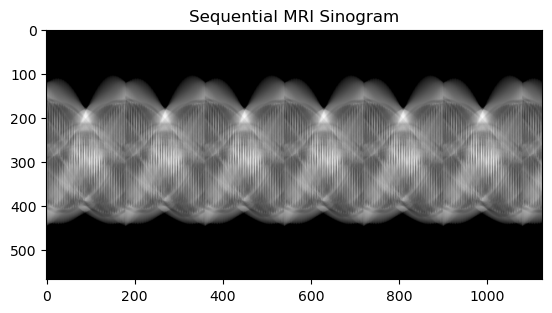

In [16]:
plot = plt.figure();
plot = plt.imshow(sinogram, cmap='grey');
plt.title("Sequential MRI Sinogram");
plt.savefig('fig/seq_sinogram.png');
plt.show(plot)

7 bins with 15 frames: 2 frames per bin.
Bin 0: 150 spokes, sinogram shape: (566, 150)
Bin 1: 150 spokes, sinogram shape: (566, 150)
Bin 2: 150 spokes, sinogram shape: (566, 150)
Bin 3: 150 spokes, sinogram shape: (566, 150)
Bin 4: 150 spokes, sinogram shape: (566, 150)
Bin 5: 150 spokes, sinogram shape: (566, 150)
Bin 6: 150 spokes, sinogram shape: (566, 150)


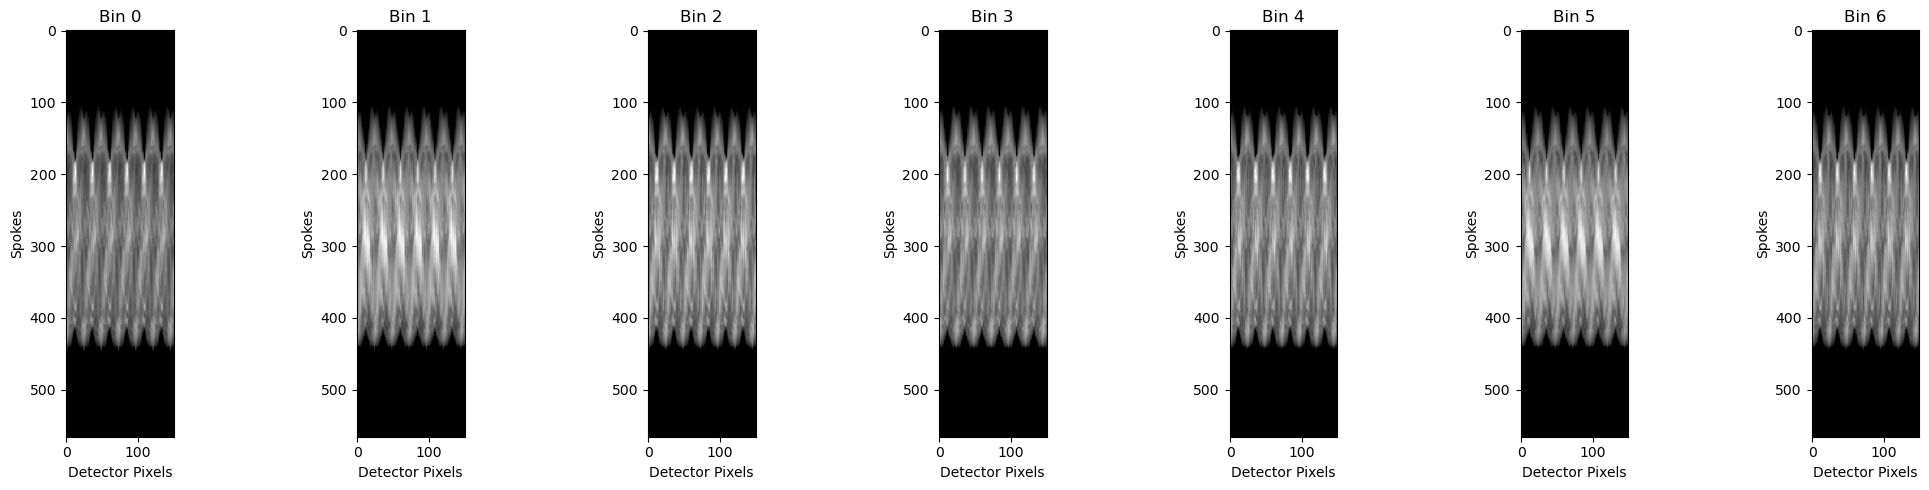

In [18]:
bins = 7;
frames_per_bin = frames // bins;

print(f"{bins} bins with {frames} frames: {frames_per_bin} frames per bin.");

bin_indices = np.floor(all_idx / frames_per_bin).astype(int); # map to bins

binned_sinograms = [];
binned_angles_rad = [];

# TODO if we approximate the pattern of breathing as changing like a sine wave
# then the same pattern is repeated approximately twice
# so we can reduce the number of bins and combine spokes
# (assuming breathing is regular)

for b in range(bins):
    bin_idx = np.where(bin_indices == b)[0]; # grab the indices for the bin
    s = sinogram[:, bin_idx];
    a = seq_angles_rad[bin_idx];

    binned_sinograms.append(s);
    binned_angles_rad.append(a);

    print(f"Bin {b}: {len(bin_idx)} spokes, sinogram shape: {s.shape}");

# map angle indices to bins
# bin contains frames/bins phases
# for each phase, determine the spokes (indicies of sinogram) that map to it
# using abs time: idx = int(np.floor(t/sample_rate));

fig, axes = plt.subplots(1, bins, figsize=(3 * bins, 5));

for b in range(bins):
    ax = axes[b];

    ax.imshow(binned_sinograms[b], cmap='grey');
    ax.set_title(f"Bin {b}");
    ax.set_xlabel("Detector Pixels");
    ax.set_ylabel("Spokes");

plt.tight_layout();
plt.show();

Starting FBP reconstruction...
Bin 0 reconstructed.
Bin 1 reconstructed.
Bin 2 reconstructed.
Bin 3 reconstructed.
Bin 4 reconstructed.
Bin 5 reconstructed.
Bin 6 reconstructed.
FBP completed.


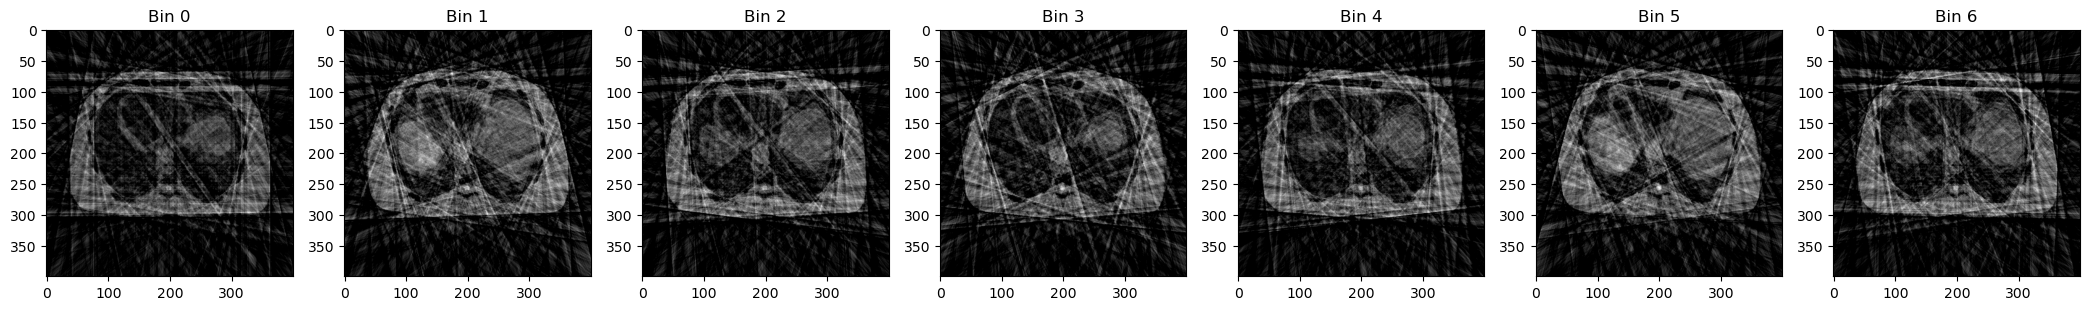

In [20]:
fbp_binned_images = [];

print(f"Starting FBP reconstruction...");
for b in range(bins):
    current_sino = binned_sinograms[b];
    current_angles = binned_angles_rad[b];
    
    # skip any empty bins
    if len(current_angles) == 0:
        print(f"Skipping Bin {b}: No data available.");
        fbp_binned_images.append(None);
        continue;
        
    bin_proj_geom = astra.create_proj_geom('parallel', 1.0, detector_width, current_angles);

    sino_id = astra.data2d.create('-sino', bin_proj_geom, current_sino.T);
    rec_id = astra.data2d.create('-vol', vol_geom);

    # configure FBP
    cfg = astra.astra_dict('FBP_CUDA');
    cfg['ReconstructionDataId'] = rec_id;
    cfg['ProjectionDataId'] = sino_id;
    cfg['FilterType'] = 'Ram-Lak';

    alg_id = astra.algorithm.create(cfg);
    astra.algorithm.run(alg_id); # run FBP

    recon_fbp = astra.data2d.get(rec_id);

    astra.algorithm.delete(alg_id);
    astra.data2d.delete(rec_id);
    astra.data2d.delete(sino_id);

    recon_fbp = np.clip(recon_fbp, 0, None);
    fbp_binned_images.append(recon_fbp);
    
    print(f"Bin {b} reconstructed.");
print(f"FBP completed.");

fig, axes = plt.subplots(1, bins, figsize=(3*  bins, 5));

for b in range(bins):
    ax = axes[b];
    ax.imshow(fbp_binned_images[b], cmap='grey');
    ax.set_title(f"Bin {b}");

plt.tight_layout();
plt.show();

Iter 0, error norm: 793277.17
Iter 1, error norm: 768818.50
Iter 2, error norm: 745671.25
Iter 3, error norm: 723770.78
Iter 4, error norm: 703053.32
Iter 5, error norm: 683450.42
Iter 6, error norm: 664903.20
Iter 7, error norm: 647351.54
Iter 8, error norm: 630744.89
Iter 9, error norm: 615024.66
Iter 10, error norm: 600143.67
Iter 11, error norm: 586056.28
Iter 12, error norm: 572716.77
Iter 13, error norm: 560081.76
Iter 14, error norm: 548111.53
Iter 15, error norm: 536768.27
Iter 16, error norm: 526010.92
Iter 17, error norm: 515805.53
Iter 18, error norm: 506118.86
Iter 19, error norm: 496919.01
Iter 20, error norm: 488175.84
Iter 21, error norm: 479862.86
Iter 22, error norm: 471950.03
Iter 23, error norm: 464412.48
Iter 24, error norm: 457227.78
Iter 25, error norm: 450371.86
Iter 26, error norm: 443825.06
Iter 27, error norm: 437566.05
Iter 28, error norm: 431574.00
Iter 29, error norm: 425833.51
Iter 30, error norm: 420326.60
Iter 31, error norm: 415036.56
Iter 32, error nor

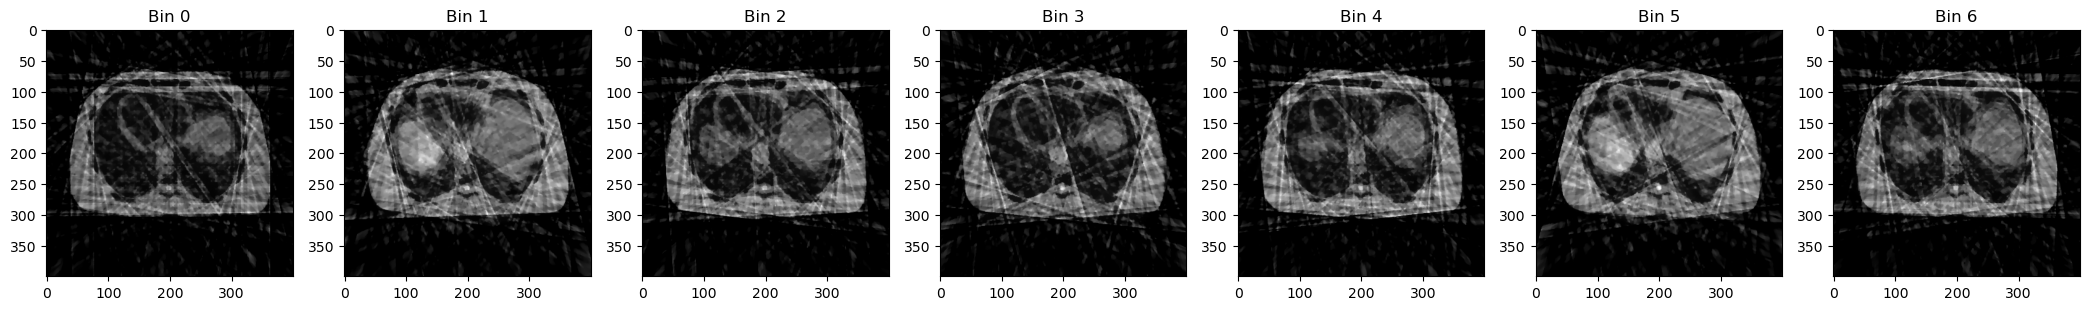

In [22]:
# Reconstruction

tv_reconstruction = [];

for b in range(bins):
    angles = binned_angles_rad[b];
    tv_recon = tv_reconstruct(binned_sinograms[b].T, fbp_binned_images[b], angles);
    tv_reconstruction.append(tv_recon);

# plot TV reconstruction by bin
fig, axes = plt.subplots(1, bins, figsize=(3*bins, 5));

for b in range(bins):
    ax = axes[b];

    ax.imshow(tv_reconstruction[b], cmap='grey');
    ax.set_title(f"Bin {b}");

plt.tight_layout();
plt.show();

# Radial MRI

Parameters:
- sample_rate: sample rate of dataset (300ms)
- frames: the number of samples in one breath cycle
- tr: repetition time, the time to acquire one spoke [s]
- breaths: the number of breaths in the simulation
- cycle_time: the time [s] of one breath
- spokes: the number of spokes collected

Given the number of frames, breaths, cycle time, and tr, calculate the corresponding number of spokes that will be taken during this time.

In [4]:
# Constants
GOLDEN_ANGLE = 111.246;
sample_rate = 0.3; # 300 ms
start_frame = 0;
end_frame = 14;
frames = end_frame - start_frame + 1; # frames to simulate (0, 14)
slice_idx = 10; 

tr = 0.4; # time to acquire 1 spoke [s] - lower bound of 400 ms
breaths = 100;
cycle_time = frames * sample_rate;
spokes = int(np.floor((breaths * cycle_time) / tr));

print(f"Simulation with {frames} frames ({start_frame} to {end_frame}) at fs={sample_rate}, TR={tr}, {breaths} breaths at {cycle_time}s each: {spokes} spokes.");
print(f"Total time: {breaths * cycle_time} s");

angles = np.arange(spokes) * GOLDEN_ANGLE;
angles = np.mod(angles, 180.0);
assert(len(angles) == spokes);

Simulation with 15 frames (0 to 14) at fs=0.3, TR=0.4, 100 breaths at 4.5s each: 1125 spokes.
Total time: 450.0


# Forward Process - Breathing Phantom
Project all spokes using radial sampling

idx: the frame of the phantom to project

In [5]:
# change this later to only take the slice to not load as much into memory (becomes 3D array, but need to change projector)
data_gt = data[start_frame:end_frame+1, :, :, :]; 
data_gt = np.rot90(data_gt, k=-1, axes=(2,3));
data_gt = data_gt.astype(float);

angles_deg = np.arange(spokes) * GOLDEN_ANGLE;
angles_deg = np.mod(angles_deg, 180.0);
angles_rad = np.deg2rad(angles_deg); # ASTRA requires radians

sinogram = np.zeros((566, spokes)); # initialize overall sinogram

# ASTRA geometry
vol_geom = astra.create_vol_geom(N, N);
detector_width = int(np.ceil(np.sqrt(N**2 + N**2))); # imitate circle=False (should be 566)

all_idx = np.empty(spokes); # spoke to frame mapping

print(f"Beginning forward projection with {spokes} spokes...");
for i in range(spokes):
    t = i * tr; # absolute time of this projection
    idx = int(np.floor(t/sample_rate)) % frames;
    all_idx[i] = idx;
    #print(f"idx={idx}");
    
    p = data_gt[idx, slice_idx, :, :]; # NxN phantom at slice, idx
    p = p.astype(float);

    proj_geom = astra.create_proj_geom('parallel', 1.0, detector_width, [angles_rad[i]]); 
    proj_id = astra.create_projector('cuda', proj_geom, vol_geom);
    
    sino_id, sino = astra.create_sino(p, proj_id); # memory obj (sino_id)
    
    sinogram[:, i] = sino[0, :]; # save this column, reverse ASTRA order

    # clean up memory
    astra.projector.delete(proj_id)
    astra.data2d.delete(sino_id);

print("Forward projection complete");

Beginning forward projection with 1125 spokes...
Forward projection complete


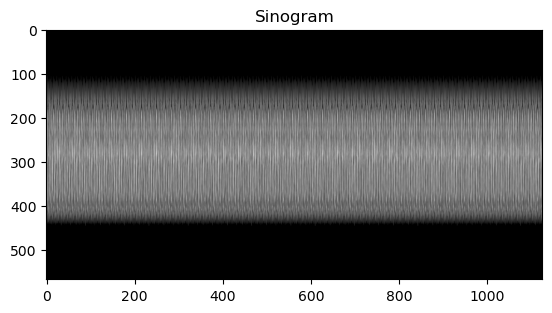

In [6]:
plot = plt.figure();
plot = plt.imshow(sinogram, cmap='grey');
plt.title("Radial MRI Sinogram");
plt.savefig('fig/radial_sinogram.png');
plt.show(plot)

## Binning

In [7]:
bins = 7;
frames_per_bin = frames // bins;

print(f"{bins} bins with {frames} frames: {frames_per_bin} frames per bin.");

bin_indices = np.floor(all_idx / frames_per_bin).astype(int); # map to bins

binned_sinograms = [];
binned_angles_rad = [];

# TODO if we approximate the pattern of breathing as changing like a sine wave
# then the same pattern is repeated approximately twice
# so we can reduce the number of bins and combine spokes
# (assuming breathing is regular)

for b in range(bins):
    bin_idx = np.where(bin_indices == b)[0]; # grab the indices for the bin
    s = sinogram[:, bin_idx];
    a = angles_rad[bin_idx];

    binned_sinograms.append(s);
    binned_angles_rad.append(a);

    print(f"Bin {b}: {len(bin_idx)} spokes, sinogram shape: {s.shape}");

# map angle indices to bins
# bin contains frames/bins phases
# for each phase, determine the spokes (indicies of sinogram) that map to it
# using abs time: idx = int(np.floor(t/sample_rate));

7 bins with 15 frames: 2 frames per bin.
Bin 0: 150 spokes, sinogram shape: (566, 150)
Bin 1: 150 spokes, sinogram shape: (566, 150)
Bin 2: 150 spokes, sinogram shape: (566, 150)
Bin 3: 150 spokes, sinogram shape: (566, 150)
Bin 4: 150 spokes, sinogram shape: (566, 150)
Bin 5: 150 spokes, sinogram shape: (566, 150)
Bin 6: 150 spokes, sinogram shape: (566, 150)


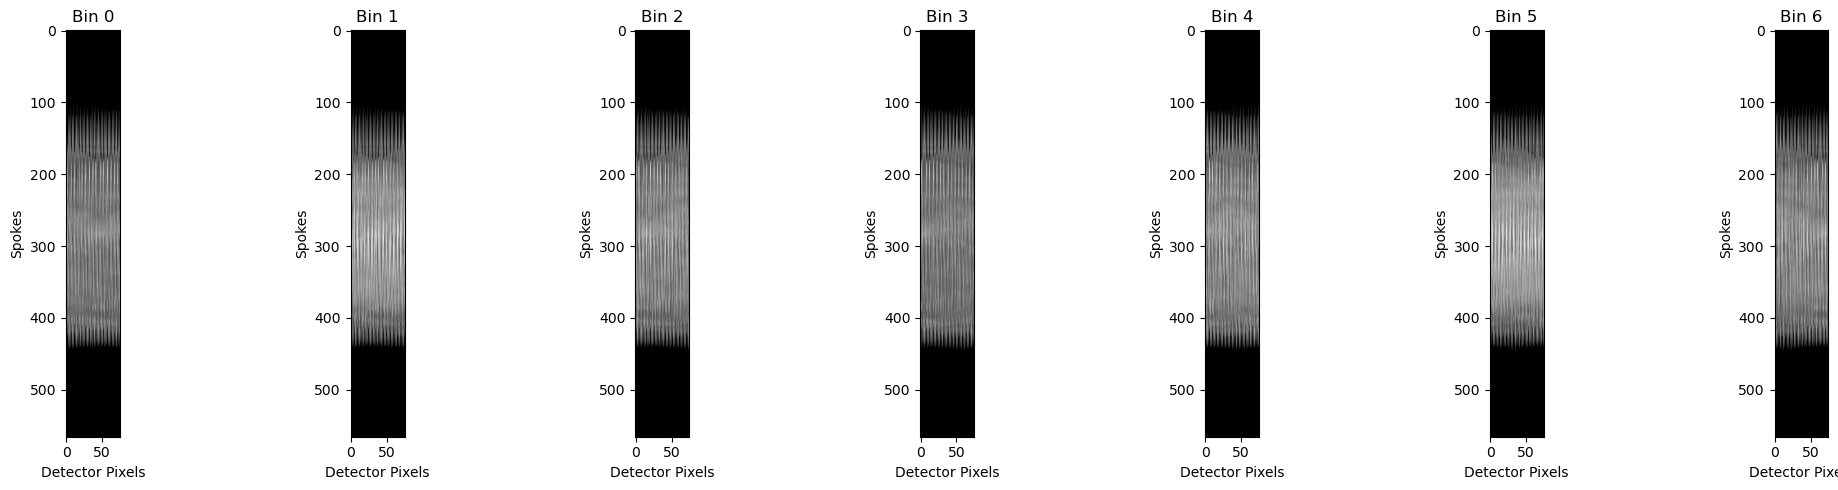

In [58]:
fig, axes = plt.subplots(1, bins, figsize=(3 * bins, 5));

for b in range(bins):
    ax = axes[b];

    ax.imshow(binned_sinograms[b], cmap='grey');
    ax.set_title(f"Bin {b}");
    ax.set_xlabel("Detector Pixels");
    ax.set_ylabel("Spokes");

plt.tight_layout();
plt.show();

In [8]:
fbp_binned_images = [];

print(f"Starting FBP reconstruction...");
for b in range(bins):
    current_sino = binned_sinograms[b];
    current_angles = binned_angles_rad[b];
    
    # skip any empty bins
    if len(current_angles) == 0:
        print(f"Skipping Bin {b}: No data available.");
        fbp_binned_images.append(None);
        continue;
        
    bin_proj_geom = astra.create_proj_geom('parallel', 1.0, detector_width, current_angles);

    sino_id = astra.data2d.create('-sino', bin_proj_geom, current_sino.T);
    rec_id = astra.data2d.create('-vol', vol_geom);

    # configure FBP
    cfg = astra.astra_dict('FBP_CUDA');
    cfg['ReconstructionDataId'] = rec_id;
    cfg['ProjectionDataId'] = sino_id;
    cfg['FilterType'] = 'Ram-Lak';

    alg_id = astra.algorithm.create(cfg);
    astra.algorithm.run(alg_id); # run FBP

    recon_fbp = astra.data2d.get(rec_id);

    astra.algorithm.delete(alg_id);
    astra.data2d.delete(rec_id);
    astra.data2d.delete(sino_id);

    recon_fbp = np.clip(recon_fbp, 0, None);
    fbp_binned_images.append(recon_fbp);
    
    print(f"Bin {b} reconstructed.");
print(f"FBP completed.");

Starting FBP reconstruction...
Bin 0 reconstructed.
Bin 1 reconstructed.
Bin 2 reconstructed.
Bin 3 reconstructed.
Bin 4 reconstructed.
Bin 5 reconstructed.
Bin 6 reconstructed.
FBP completed.


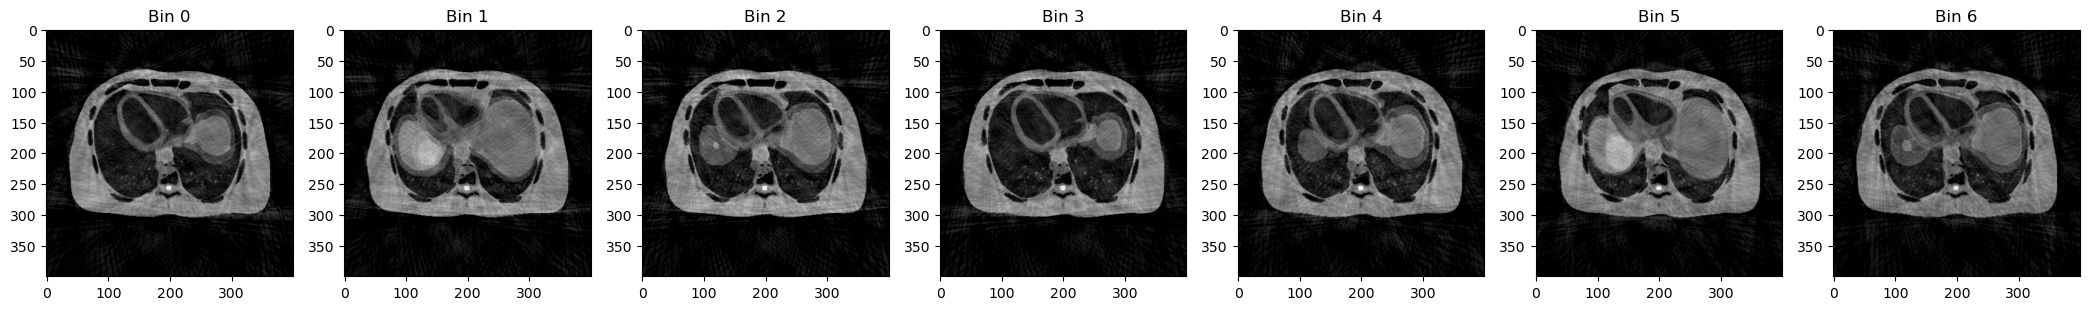

In [9]:
# plot raw FBP reconstructions by bin

fig, axes = plt.subplots(1, bins, figsize=(3*  bins, 5));

for b in range(bins):
    ax = axes[b];
    ax.imshow(fbp_binned_images[b], cmap='grey');
    ax.set_title(f"Bin {b}");

plt.tight_layout();
plt.show();

In [21]:
# more information about TV below

def tv_reconstruct(sinogram, fbp_recon, bin_angles):
    ''' TV reconstruction algorithm.
        sinogram: raw sinogram data
        fbp_recon: initial guess from FBP
        bin_angles: the angles corresponding to this bin
    '''
    bin_proj_geom = astra.create_proj_geom('parallel', 1.0, detector_width, bin_angles);
    proj_id = astra.create_projector('cuda', bin_proj_geom, vol_geom);
    
    f_measured = sinogram; # transpose from ASTRA format
    u = fbp_recon.copy(); # initial guess of FBP of sinogram
    
    iterations = 100;
    learning_rate = 1e-6; # step size
    lambda_tv = 0.08; # aggressiveness of TV (higher is more aggressive smoothing)
    
    for i in range(iterations):
        # data fidelity
        sino_id, Au = astra.create_sino(u, proj_id);
        error_sino = Au - f_measured; # should this be normalized?
    
        err_vol_id, gradient_image = astra.create_backprojection(error_sino, proj_id);
    
        u_updated = u - (learning_rate * gradient_image);
    
        # denoising
        u = denoise_tv_chambolle(u_updated, weight=lambda_tv);
        u = np.clip(u, 0, None); # enforce non-negativity
    
        # cleanup
        astra.data2d.delete(sino_id);
        astra.data2d.delete(err_vol_id);
    
        print(f"Iter {i}, error norm: {np.linalg.norm(error_sino):.2f}");
    return u;

In [11]:
# run TV reconstruction algorithm on each bin

tv_reconstruction = [];

for b in range(bins):
    angles = binned_angles_rad[b];
    tv_recon = tv_reconstruct(binned_sinograms[b].T, fbp_binned_images[b], angles);
    tv_reconstruction.append(tv_recon)

Iter 0, error norm: 247436.03
Iter 1, error norm: 239936.92
Iter 2, error norm: 232898.37
Iter 3, error norm: 226297.61
Iter 4, error norm: 220110.30
Iter 5, error norm: 214309.82
Iter 6, error norm: 208873.32
Iter 7, error norm: 203778.05
Iter 8, error norm: 199003.13
Iter 9, error norm: 194529.52
Iter 10, error norm: 190447.37
Iter 11, error norm: 186500.23
Iter 12, error norm: 182804.90
Iter 13, error norm: 179445.27
Iter 14, error norm: 176176.62
Iter 15, error norm: 173217.34
Iter 16, error norm: 170324.62
Iter 17, error norm: 167712.47
Iter 18, error norm: 165147.01
Iter 19, error norm: 162835.93
Iter 20, error norm: 160555.05
Iter 21, error norm: 158502.86
Iter 22, error norm: 156467.08
Iter 23, error norm: 154636.44
Iter 24, error norm: 152812.26
Iter 25, error norm: 151172.34
Iter 26, error norm: 149531.75
Iter 27, error norm: 148055.18
Iter 28, error norm: 146572.31
Iter 29, error norm: 145235.64
Iter 30, error norm: 143887.79
Iter 31, error norm: 142670.30
Iter 32, error nor

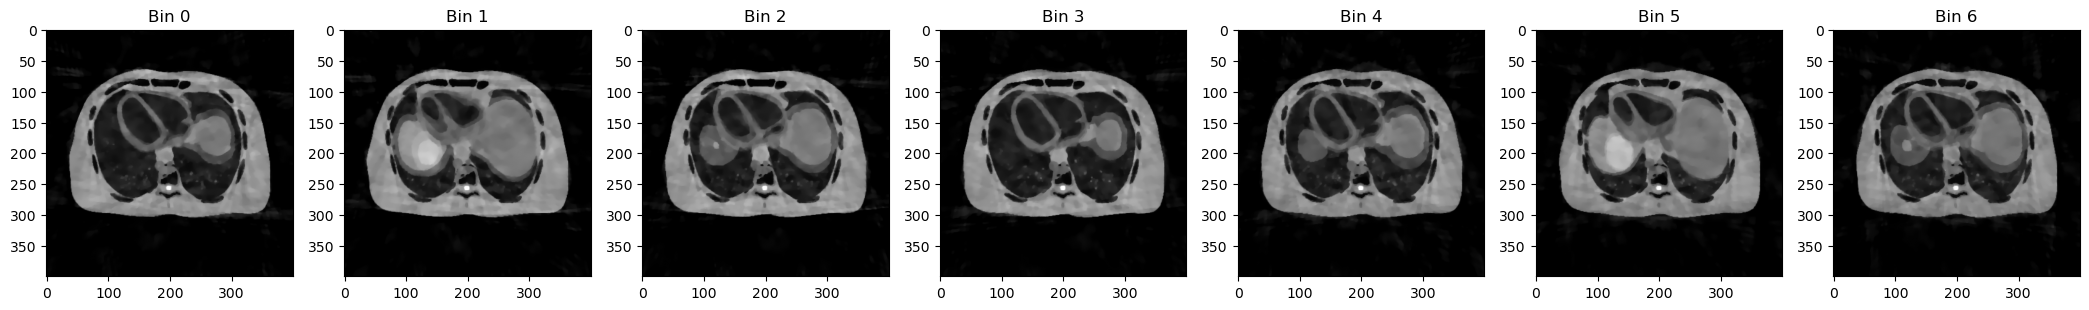

In [12]:
# plot TV reconstruction by bin

fig, axes = plt.subplots(1, bins, figsize=(3*bins, 5));

for b in range(bins):
    ax = axes[b];

    ax.imshow(tv_reconstruction[b], cmap='grey');
    ax.set_title(f"Bin {b}");

plt.tight_layout();
plt.show();

# Backward Radon Process - No Binning
Reconstruct an image using all spokes

In [6]:
# create new proj geometry with all angles
all_proj_geom = astra.create_proj_geom('parallel', 1.0, detector_width, angles_rad); 

# create pointer to sinogram
sino_overall_id = astra.data2d.create('-sino', all_proj_geom, sinogram.T);

# create C++ obj to hold reconstruction
rec_id = astra.data2d.create('-vol', vol_geom); 

# configure FBP
cfg = astra.astra_dict('FBP_CUDA');
cfg['ReconstructionDataId'] = rec_id;
cfg['ProjectionDataId'] = sino_overall_id;
cfg['FilterType'] = 'Ram-Lak';

alg_id = astra.algorithm.create(cfg);
astra.algorithm.run(alg_id);

reconstructed_fbp = astra.data2d.get(rec_id);

# cleanup
astra.algorithm.delete(alg_id);
astra.data2d.delete(rec_id);
astra.data2d.delete(sino_overall_id);

# clip negative values
reconstructed_fbp = np.clip(reconstructed_fbp, 0, None);
#reconstructed_fbp = np.rot90(reconstructed_fbp, k=-1, axes=(0,1));

print(f"Recon Min: {np.min(reconstructed_fbp)}, Max: {np.max(reconstructed_fbp)}")

Recon Min: 0.0, Max: 155.79405212402344


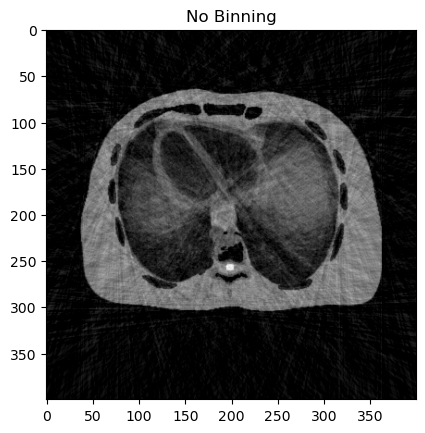

In [7]:
plot = plt.figure();
plot = plt.imshow(reconstructed_fbp, cmap='grey');
plt.title("No Binning");
plt.savefig('fig/example_astra_all.png');
plt.show(plot)

# 1-Frame Example (ASTRA)

In [75]:
# Example
GOLDEN_ANGLE = 111.246;
ex_gt = data[0, 10, :, :];
ex_gt = np.rot90(ex_gt, k=-1, axes=(0,1));
ex_gt = ex_gt.astype(float)

angles_deg = np.arange(100) * GOLDEN_ANGLE;
angles_deg = np.mod(angles_deg, 180.0);
angles_rad = np.deg2rad(angles_deg); # ASTRA requires radians

# ASTRA geometry
vol_geom = astra.create_vol_geom(N, N);
detector_width = int(np.ceil(np.sqrt(N**2 + N**2))); # imitate circle=False (should be 566)
proj_geom = astra.create_proj_geom('parallel', 1.0, detector_width, angles_rad); # parallel beam
proj_id = astra.create_projector('cuda', proj_geom, vol_geom);

# forward process
print(f"Running forward radon...");
sino_id, ex_sinogram = astra.create_sino(ex_gt, proj_id); # memory obj (sino_id)
print(f"Completed forward radon.");

# backward process
rec_id = astra.data2d.create('-vol', vol_geom); # create C++ obj to hold reconstruction

# configure FBP
cfg = astra.astra_dict('FBP_CUDA');
cfg['ReconstructionDataId'] = rec_id;
cfg['ProjectionDataId'] = sino_id;
cfg['FilterType'] = 'Ram-Lak';

alg_id = astra.algorithm.create(cfg);

print(f"Running FBP (id {alg_id})...");
astra.algorithm.run(alg_id);

ex_reconstructed = astra.data2d.get(rec_id);
print(f"FBP complete.");

# cleanup
astra.algorithm.delete(alg_id);
astra.data2d.delete(rec_id);
astra.data2d.delete(sino_id);

# clip negative values
ex_reconstructed = np.clip(ex_reconstructed, 0, None);

# normalize
ex_gt_norm = ex_gt / np.max(ex_gt);
ex_reconstructed_norm = ex_reconstructed / np.max(ex_reconstructed);

# calculate difference
diff = np.abs(ex_gt_norm - ex_reconstructed_norm);

print(f"Ground Truth Min: {np.min(ex_gt)}, Max: {np.max(ex_gt)}")
print(f"Recon Min: {np.min(ex_reconstructed)}, Max: {np.max(ex_reconstructed)}")
print(f"Diff Min: {np.min(diff)}, Max: {np.max(diff)}")

Ground Truth Min: 0.0, Max: 139.0
Recon Min: 0.0, Max: 145.6977996826172
Diff Min: 0.0, Max: 0.3000432593788175


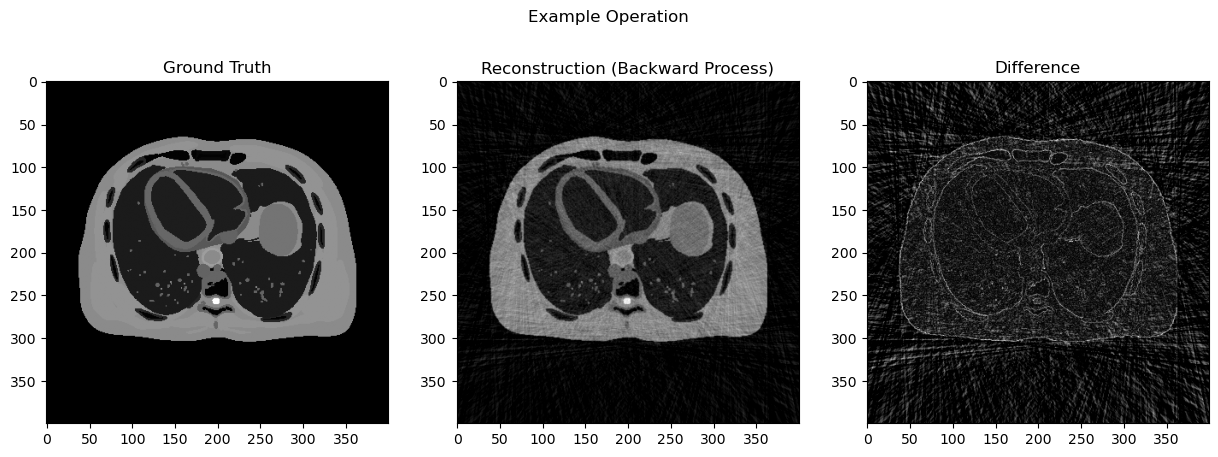

In [76]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5));
fig.suptitle('Example Operation');

ax1.set_title('Ground Truth');
im1 = ax1.imshow(ex_gt, cmap='grey');
ax2.set_title('Reconstruction (Backward Process)');
im2 = ax2.imshow(ex_reconstructed, cmap='grey');
ax3.set_title('Difference');
im3 = ax3.imshow(diff, cmap='grey');

plt.savefig('fig/Example.png');
plt.show();

# TV Iterative Reconstruction
$ \displaystyle \min_{u} \frac{1}{2} ||Au - f||_2^2 + \lambda TV(u) $

Where $A$ is the forward radon process, $A^T$ is the backward radon process, $u$ is the initial guess, and $f$ is the raw sinogram data. 
$ \nabla = A^T(Au-f)$

In [ ]:
plot = plt.figure();
plot = plt.imshow(ex_sinogram.T, cmap='grey');
plt.title("Sinogram");
#plt.savefig('fig/example_astra_all.png');
plt.show(plot)

In [83]:
f_measured = ex_sinogram; # transpose from ASTRA format
u = ex_reconstructed.copy(); # initial guess of FBP of sinogram

iterations = 100;
learning_rate = 1e-6; # step size
lambda_tv = 0.08; # aggressiveness of TV (higher is more aggressive smoothing)

for i in range(iterations):
    # data fidelity step
    sino_id, Au = astra.create_sino(u, proj_id);
    error_sino = Au - f_measured; # should this be normalized?

    err_vol_id, gradient_image = astra.create_backprojection(error_sino, proj_id);

    u_updated = u - (learning_rate * gradient_image);

    # denoising
    u = denoise_tv_chambolle(u_updated, weight=lambda_tv);
    u = np.clip(u, 0, None); # enforce non-negativity

    # cleanup
    astra.data2d.delete(sino_id);
    astra.data2d.delete(err_vol_id);

    print(f"Iter {i}, error norm: {np.linalg.norm(error_sino):.2f}");

Iter 0, error norm: 136805.98
Iter 1, error norm: 133073.14
Iter 2, error norm: 129266.84
Iter 3, error norm: 125613.52
Iter 4, error norm: 122102.01
Iter 5, error norm: 118728.12
Iter 6, error norm: 115487.97
Iter 7, error norm: 112377.26
Iter 8, error norm: 109391.60
Iter 9, error norm: 106527.13
Iter 10, error norm: 103778.79
Iter 11, error norm: 101142.05
Iter 12, error norm: 98612.53
Iter 13, error norm: 96186.12
Iter 14, error norm: 93858.38
Iter 15, error norm: 91625.68
Iter 16, error norm: 89484.64
Iter 17, error norm: 87431.83
Iter 18, error norm: 85463.29
Iter 19, error norm: 83575.38
Iter 20, error norm: 81764.72
Iter 21, error norm: 80028.35
Iter 22, error norm: 78363.28
Iter 23, error norm: 76766.59
Iter 24, error norm: 75235.08
Iter 25, error norm: 73765.89
Iter 26, error norm: 72356.32
Iter 27, error norm: 71003.82
Iter 28, error norm: 69705.86
Iter 29, error norm: 68477.21
Iter 30, error norm: 67281.95
Iter 31, error norm: 66149.17
Iter 32, error norm: 65062.37
Iter 33,

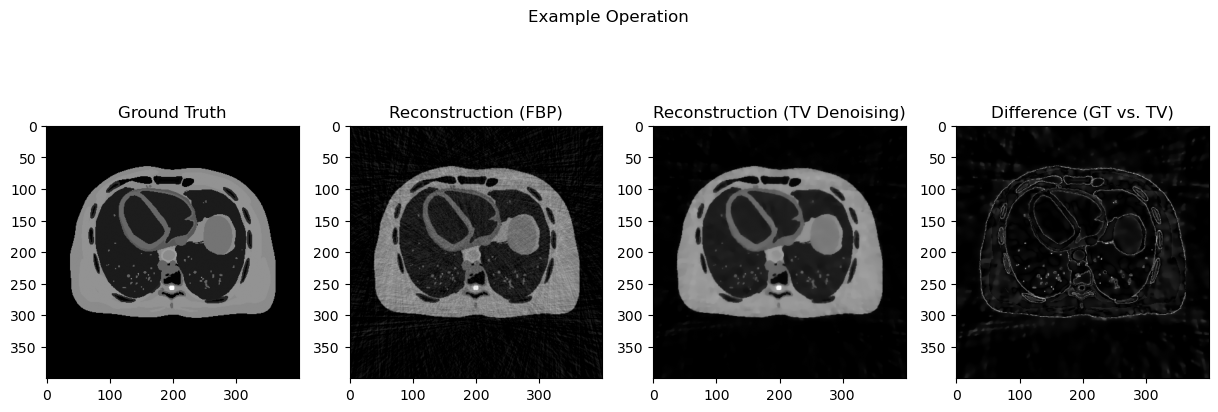

In [90]:
u_norm = u / np.max(u); # normalize
diff = np.abs(ex_gt_norm - u_norm);

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 5));
fig.suptitle('Example Operation');

ax1.set_title('Ground Truth');
im1 = ax1.imshow(ex_gt, cmap='grey');

ax2.set_title('Reconstruction (FBP)');
im2 = ax2.imshow(ex_reconstructed, cmap='grey');

ax3.set_title('Reconstruction (TV Denoising)');
im3 = ax3.imshow(u_norm, cmap='grey');

ax4.set_title('Difference (GT vs. TV)');
im4 = ax4.imshow(diff, cmap='grey');

plt.savefig('fig/Example.png');
plt.show();

# Example: Static Image, 100 Spokes (skimage)

Example of forward/backward projection using the Scikit Image library

In [ ]:
# Example
GOLDEN_ANGLE = 111.246;
ex_gt = data[0, 10, :, :];
ex_gt = np.rot90(ex_gt, k=-1, axes=(0,1));
ex_gt = ex_gt.astype(float)

angles = np.arange(100) * GOLDEN_ANGLE;
angles = np.mod(angles, 180.0);

# forward process
ex_sinogram = radon(ex_gt, theta=angles, circle=False);

# backward process
ex_reconstructed = iradon(ex_sinogram, theta=angles, filter_name='ramp', circle=False);

# clip negative values
ex_reconstructed = np.clip(ex_reconstructed, 0, None);

# normalize
ex_gt_norm = ex_gt / np.max(ex_gt);
ex_reconstructed_norm = ex_reconstructed / np.max(ex_reconstructed);

# calculate difference
diff = np.abs(ex_gt_norm - ex_reconstructed_norm);

print(f"Ground Truth Min: {np.min(ex_gt)}, Max: {np.max(ex_gt)}")
print(f"Recon Min: {np.min(ex_reconstructed)}, Max: {np.max(ex_reconstructed)}")
print(f"Diff Min: {np.min(diff)}, Max: {np.max(diff)}")

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5));
fig.suptitle('Example Operation');

ax1.set_title('Ground Truth');
im1 = ax1.imshow(ex_gt, cmap='grey');

ax2.set_title('Reconstruction (Backward Process)');
im2 = ax2.imshow(ex_reconstructed, cmap='grey');

ax3.set_title('Difference');
im3 = ax3.imshow(diff, cmap='grey');

plt.savefig('fig/Example.png');
plt.show();